In [1]:
from google.colab import drive
from pathlib import Path
import subprocess, os, json, time

drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/kride-track-b")
ROOT.mkdir(parents=True, exist_ok=True)

INPUT_DIR = ROOT / "cogvideo_inputs"
OUT_DIR = ROOT / "cogvideo_outputs"
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
!nvidia-smi

Mounted at /content/drive
ROOT: /content/drive/MyDrive/kride-track-b
Wed May 27 03:44:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |   

In [2]:
!apt-get update -y
!apt-get install -y ffmpeg --quiet
!pip install -q --no-cache-dir --force-reinstall "Pillow==10.4.0"

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main

In [ ]:
import torch, diffusers, transformers, accelerate, huggingface_hub

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

torch: 2.11.0+cu128
cuda: True
diffusers: 0.38.0
transformers: 5.9.0
accelerate: 1.13.0
huggingface_hub: 1.16.4


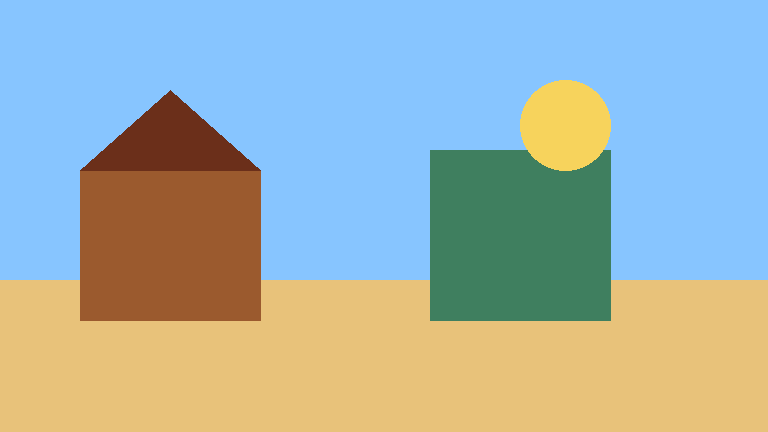

In [3]:
from PIL import Image, ImageDraw
from pathlib import Path
from IPython.display import display

sample_image = INPUT_DIR / "sample_travel_scene.png"

if not sample_image.exists():
    img = Image.new("RGB", (768, 432), "#87c5ff")
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 280, 768, 432], fill="#e8c27a")
    draw.rectangle([80, 170, 260, 320], fill="#9b5a2e")
    draw.polygon([(80, 170), (170, 90), (260, 170)], fill="#6b2f1a")
    draw.rectangle([430, 150, 610, 320], fill="#3f7f5f")
    draw.ellipse([520, 80, 610, 170], fill="#f7d35c")
    img.save(sample_image)

display(Image.open(sample_image))

In [ ]:
!pip uninstall -y Pillow PIL pillow
!pip install -q --no-cache-dir --force-reinstall "Pillow==10.4.0"

Found existing installation: pillow 12.2.0
Uninstalling pillow-12.2.0:
  Successfully uninstalled pillow-12.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 81.8 MB/s eta 0:00:00


In [ ]:
import os
os.kill(os.getpid(), 9)

In [4]:
from pathlib import Path
import subprocess, json, math, shutil
from PIL import Image
from IPython.display import Video, display

ROOT = Path("/content/drive/MyDrive/kride-track-b")
INPUT_IMAGE = ROOT / "cogvideo_inputs" / "sample_travel_scene.png"
OUT_DIR = ROOT / "cogvideo_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FALLBACK_MP4 = OUT_DIR / "cogvideo_fallback_panzoom.mp4"
ROUTE_JSON = OUT_DIR / "cogvideo_route_result.json"

caption = "A colorful travel scene with a cute character walking near a house"

def route_video_model(caption: str) -> str:
    dynamic_keywords = [
        "person", "people", "man", "woman", "girl", "boy", "child",
        "crowd", "dog", "cat", "animal", "character", "doodle",
        "dance", "walking", "running", "moving"
    ]
    text = caption.lower()
    return "cogvideox" if any(word in text for word in dynamic_keywords) else "3d_animation"

route = route_video_model(caption)

route_result = {
    "caption": caption,
    "route": route,
    "cogvideo_status": "fallback_used",
    "fallback_reason": "CogVideoX-2b caused Colab session crash on T4; using deterministic pan/zoom fallback for pipeline validation.",
    "input_image": str(INPUT_IMAGE),
    "output_video": str(FALLBACK_MP4),
}

ROUTE_JSON.write_text(json.dumps(route_result, ensure_ascii=False, indent=2), encoding="utf-8")

print(json.dumps(route_result, ensure_ascii=False, indent=2))

{
  "caption": "A colorful travel scene with a cute character walking near a house",
  "route": "cogvideox",
  "cogvideo_status": "fallback_used",
  "fallback_reason": "CogVideoX-2b caused Colab session crash on T4; using deterministic pan/zoom fallback for pipeline validation.",
  "input_image": "/content/drive/MyDrive/kride-track-b/cogvideo_inputs/sample_travel_scene.png",
  "output_video": "/content/drive/MyDrive/kride-track-b/cogvideo_outputs/cogvideo_fallback_panzoom.mp4"
}


In [5]:
# 이미지 1장을 부드러운 pan/zoom 영상으로 변환
# 6초, 8fps, 512x320

subprocess.run([
    "ffmpeg", "-y",
    "-loop", "1",
    "-i", str(INPUT_IMAGE),
    "-vf",
    "scale=640:-1,"
    "zoompan=z='min(zoom+0.0015,1.08)':"
    "x='iw/2-(iw/zoom/2)':"
    "y='ih/2-(ih/zoom/2)':"
    "d=48:s=512x320:fps=8,"
    "format=yuv420p",
    "-t", "6",
    "-c:v", "libx264",
    "-preset", "veryfast",
    "-crf", "23",
    str(FALLBACK_MP4),
], check=True)

print("✅ fallback CogVideo-style video:", FALLBACK_MP4)
display(Video(str(FALLBACK_MP4), embed=True, width=640))

✅ fallback CogVideo-style video: /content/drive/MyDrive/kride-track-b/cogvideo_outputs/cogvideo_fallback_panzoom.mp4


In [6]:
!pip install -q --no-cache-dir numpy==1.26.4 pandas==2.1.4 mlflow dagshub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 206.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 161.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 163.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 324.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 258.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 348.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 228.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 353.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 440.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 399.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 294.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/kride-track-b")

for p in [
    ROOT / "cogvideo_inputs" / "sample_travel_scene.png",
    ROOT / "cogvideo_outputs" / "cogvideo_fallback_panzoom.mp4",
    ROOT / "cogvideo_outputs" / "cogvideo_route_result.json",
]:
    print(p.name, p.exists(), round(p.stat().st_size / 1024 / 1024, 2) if p.exists() else 0)

sample_travel_scene.png True 0.0
cogvideo_fallback_panzoom.mp4 True 0.03
cogvideo_route_result.json True 0.0


input image: /content/drive/MyDrive/kride-track-b/cogvideo_inputs/sample_travel_scene.png


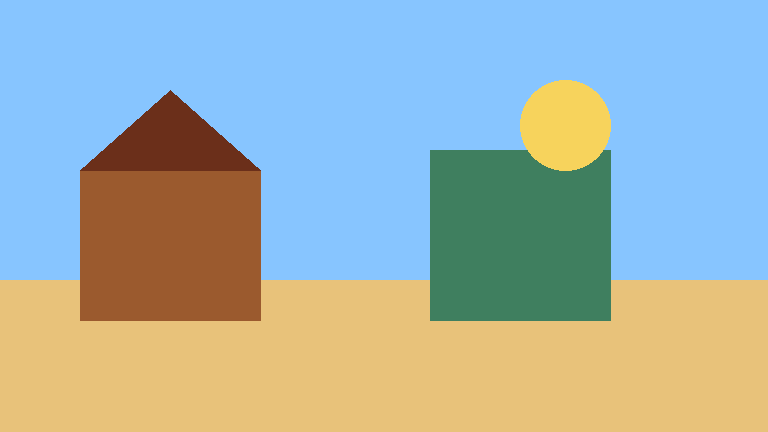

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw
from IPython.display import display

ROOT = Path("/content/drive/MyDrive/kride-track-b")
INPUT_DIR = ROOT / "cogvideo_inputs"
INPUT_DIR.mkdir(parents=True, exist_ok=True)

sample_image = INPUT_DIR / "sample_travel_scene.png"

if not sample_image.exists():
    img = Image.new("RGB", (768, 432), "#87c5ff")
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 280, 768, 432], fill="#e8c27a")
    draw.rectangle([80, 170, 260, 320], fill="#9b5a2e")
    draw.polygon([(80, 170), (170, 90), (260, 170)], fill="#6b2f1a")
    draw.rectangle([430, 150, 610, 320], fill="#3f7f5f")
    draw.ellipse([520, 80, 610, 170], fill="#f7d35c")
    img.save(sample_image)

print("input image:", sample_image)
display(Image.open(sample_image))

In [1]:
!pip install -q --no-cache-dir --force-reinstall numpy==1.26.4 pandas==2.1.4
!pip install -q --no-cache-dir mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 217.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 221.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 206.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 228.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 91.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have nu

In [2]:
import numpy, pandas, mlflow
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("mlflow:", mlflow.__version__)

numpy: 1.26.4
pandas: 2.1.4
mlflow: 3.12.0


In [3]:
import os, mlflow
from google.colab import userdata
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/kride-track-b")

INPUT_IMAGE = ROOT / "cogvideo_inputs" / "sample_travel_scene.png"
FALLBACK_MP4 = ROOT / "cogvideo_outputs" / "cogvideo_fallback_panzoom.mp4"
ROUTE_JSON = ROOT / "cogvideo_outputs" / "cogvideo_route_result.json"

DAGSHUB_USERNAME = "myelin24m"
DAGSHUB_REPO = "Kride"
DAGSHUB_TOKEN = userdata.get("DAGSHUB_TOKEN")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN
os.environ["MLFLOW_TRACKING_URI"] = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("track-b-colab-cogvideox")

with mlflow.start_run(run_name="cogvideox-t4-fallback-panzoom") as run:
    mlflow.log_param("route", "cogvideox")
    mlflow.log_param("model_attempted", "THUDM/CogVideoX-2b")
    mlflow.log_param("gpu", "Tesla T4")
    mlflow.log_param("status", "fallback_used")
    mlflow.log_param("fallback_type", "ffmpeg_panzoom")
    mlflow.log_param("failure_reason", "Colab session crashed while loading/running CogVideoX-2b on T4")

    mlflow.log_artifact(str(INPUT_IMAGE), artifact_path="input_image")
    mlflow.log_artifact(str(ROUTE_JSON), artifact_path="route")
    mlflow.log_metric("fallback_size_mb", FALLBACK_MP4.stat().st_size / 1024 / 1024)
    mlflow.log_artifact(str(FALLBACK_MP4), artifact_path="cogvideo_fallback")

    print("✅ CogVideo fallback DagsHub 기록 완료")
    print("Run ID:", run.info.run_id)
    print("MLflow URI:", mlflow.get_tracking_uri())

2026/05/27 03:58:26 INFO mlflow.tracking.fluent: Experiment with name 'track-b-colab-cogvideox' does not exist. Creating a new experiment.


✅ CogVideo fallback DagsHub 기록 완료
Run ID: 9de703f798934073828f98462b704cea
MLflow URI: https://dagshub.com/myelin24m/Kride.mlflow
🏃 View run cogvideox-t4-fallback-panzoom at: https://dagshub.com/myelin24m/Kride.mlflow/#/experiments/19/runs/9de703f798934073828f98462b704cea
🧪 View experiment at: https://dagshub.com/myelin24m/Kride.mlflow/#/experiments/19
